# Air Quality Classification


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import joblib

print("Libraries imported successfully!")


Libraries imported successfully!


## connect to MySQL


In [2]:
connection = mysql.connector.connect(
    host="localhost",
    user="air_user",
    password="root",
    database="air_quality_db"
)

print("MySQL Connected:", connection.is_connected())


MySQL Connected: True


# load Dataset


In [3]:
query = "SELECT * FROM air_quality"
df = pd.read_sql(query, connection)

print("Dataset shape:", df.shape)
display(df.head())
print(df.columns.tolist())


Dataset shape: (3549, 11)


C:\Users\P.MANISH KUMAR\AppData\Local\Temp\ipykernel_32776\3281616632.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Andhra Pradesh,Kakinada,"Rama Rao Peta, Kakinada - APPCB",25-08-2026 17.00,16.962488,82.229513,NO2,27.0,51.0,39.0
1,India,Andhra Pradesh,Kurnool,"Sita Rama Nagar, Kurnool - APPCB",25-08-2026 17.00,15.834110,78.028546,PM10,28.0,47.0,38.0
2,India,Andhra Pradesh,Kurnool,"Sita Rama Nagar, Kurnool - APPCB",25-08-2026 17.00,15.834110,78.028546,NH3,6.0,6.0,6.0
3,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",25-08-2026 17.00,16.186555,81.132190,PM10,52.0,64.0,55.0
4,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",25-08-2026 17.00,16.186555,81.132190,NH3,2.0,4.0,4.0


['country', 'state', 'city', 'station', 'last_update', 'latitude', 'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max', 'pollutant_avg']


## check Target


In [4]:
if "pollutant_avg" not in df.columns:
    raise ValueError("Column 'pollutant_avg' was not found. Check your database table.")

df["pollutant_avg"] = pd.to_numeric(df["pollutant_avg"], errors="coerce")
df = df.dropna(subset=["pollutant_avg"]).copy()

print(df["pollutant_avg"].describe())


count    3219.000000
mean       29.575645
std        27.780874
min         0.000000
25%         9.000000
50%        22.000000
75%        41.000000
max       188.000000
Name: pollutant_avg, dtype: float64


## Create Classification Target


In [5]:
# Rank-based quantiles guarantee three groups when at least 3 rows exist.
if len(df) < 3:
    raise ValueError("At least 3 rows are required to create Low/Medium/High classes.")

df["pollution_class"] = pd.qcut(
    df["pollutant_avg"].rank(method="first"),
    q=3,
    labels=["Low", "Medium", "High"]
)

print(df["pollution_class"].value_counts())
display(df[["pollutant_avg", "pollution_class"]].head())


pollution_class
Low       1073
Medium    1073
High      1073
Name: count, dtype: int64


,pollutant_avg,pollution_class
0,39.0,High
1,38.0,High
2,6.0,Low
3,55.0,High
4,4.0,Low


## Class Distribution


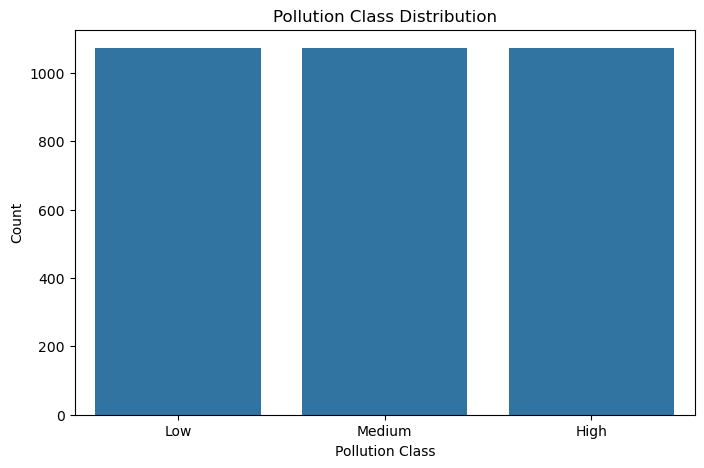

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="pollution_class")
plt.title("Pollution Class Distribution")
plt.xlabel("Pollution Class")
plt.ylabel("Count")
plt.show()


## Create Features and Target


In [7]:
X = df.drop(columns=["pollutant_avg", "pollution_class"], errors="ignore").copy()
y = df["pollution_class"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (3219, 10)
y shape: (3219,)


## Process Date Columns


In [8]:
# Process last_update if present.
if "last_update" in X.columns:
    X["last_update"] = pd.to_datetime(X["last_update"], errors="coerce", dayfirst=True)
    X["year"] = X["last_update"].dt.year
    X["month"] = X["last_update"].dt.month
    X["day"] = X["last_update"].dt.day
    X["hour"] = X["last_update"].dt.hour
    X = X.drop(columns=["last_update"])

# Automatically process any remaining datetime columns.
for col in X.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns.tolist():
    X[col + "_year"] = X[col].dt.year
    X[col + "_month"] = X[col].dt.month
    X[col + "_day"] = X[col].dt.day
    X = X.drop(columns=[col])

print("Date processing completed.")
print(X.dtypes)


Date processing completed.
country           object
state             object
city              object
station           object
latitude         float64
longitude        float64
pollutant_id      object
pollutant_min    float64
pollutant_max    float64
year             float64
month            float64
day              float64
hour             float64
dtype: object


##  Encode Categorical Columns


In [9]:
categorical_columns = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("Encoded columns:", categorical_columns)


Encoded columns: ['country', 'state', 'city', 'station', 'pollutant_id']


## Convert Remaining Features to Numeric


In [10]:
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

X = X.dropna(axis=1, how="all")

print("Remaining features:", X.columns.tolist())
print("Total missing values:", X.isnull().sum().sum())


Remaining features: ['country', 'state', 'city', 'station', 'latitude', 'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max']
Total missing values: 0


## Impute Missing Values


In [11]:
imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("Total missing values after imputation:", X_imputed.isnull().sum().sum())


Total missing values after imputation: 0


##  Train/Test Split


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\nTraining classes:")
print(y_train.value_counts())
print("\nTesting classes:")
print(y_test.value_counts())


X_train: (2575, 9)
X_test: (644, 9)

Training classes:
pollution_class
High      859
Low       858
Medium    858
Name: count, dtype: int64

Testing classes:
pollution_class
Low       215
Medium    215
High      214
Name: count, dtype: int64


## Feature Scaling


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")


Scaling completed.


## Train Models


In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf", random_state=42)
}

predictions = {}
results_list = []

for name, model in models.items():
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    predictions[name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results_list.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))



Logistic Regression
Accuracy: 0.9316770186335404
Precision: 0.93170738637715
Recall: 0.9316770186335404
F1 Score: 0.9311774817458633

Classification Report:
              precision    recall  f1-score   support

        High       0.95      0.93      0.94       214
         Low       0.93      0.99      0.95       215
      Medium       0.92      0.87      0.90       215

    accuracy                           0.93       644
   macro avg       0.93      0.93      0.93       644
weighted avg       0.93      0.93      0.93       644


Decision Tree
Accuracy: 0.9161490683229814
Precision: 0.9157836139976495
Recall: 0.9161490683229814
F1 Score: 0.915873816225367

Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.92      0.92       214
         Low       0.94      0.96      0.95       215
      Medium       0.88      0.87      0.87       215

    accuracy                           0.92       644
   macro avg       0.92      0.92   

## Cell 15 — Model Comparison


In [15]:
results = pd.DataFrame(results_list).sort_values(by="Accuracy", ascending=False)
display(results)

best_model_name = results.iloc[0]["Model"]
best_accuracy = results.iloc[0]["Accuracy"]

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)


,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.933230,0.932895,0.933230,0.932938
0,Logistic Regression,0.931677,0.931707,0.931677,0.931177
4,SVM,0.925466,0.925775,0.925466,0.924982
1,Decision Tree,0.916149,0.915784,0.916149,0.915874
3,KNN,0.791925,0.793631,0.791925,0.789040


Best Model: Random Forest
Best Accuracy: 0.9332298136645962


##  Plot Accuracy


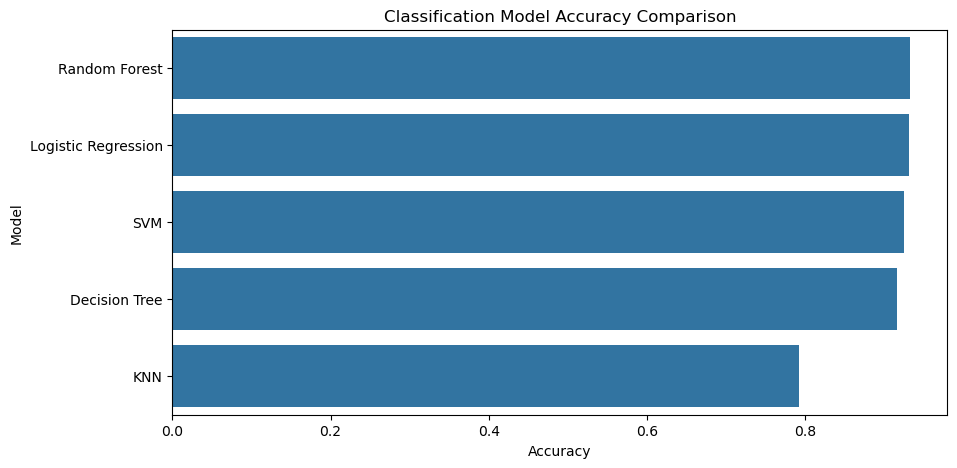

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results, x="Accuracy", y="Model")
plt.title("Classification Model Accuracy Comparison")
plt.show()


## Cell 17 — Confusion Matrices


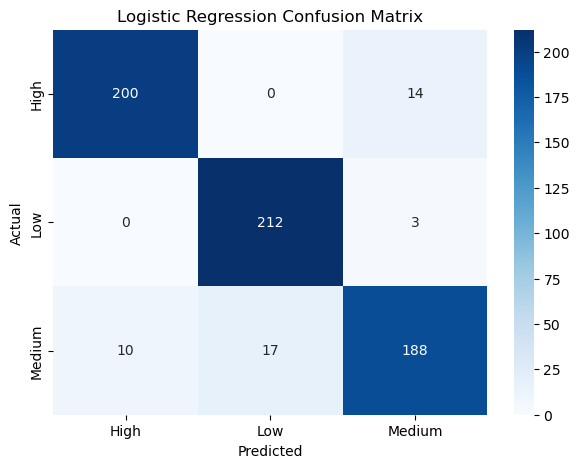

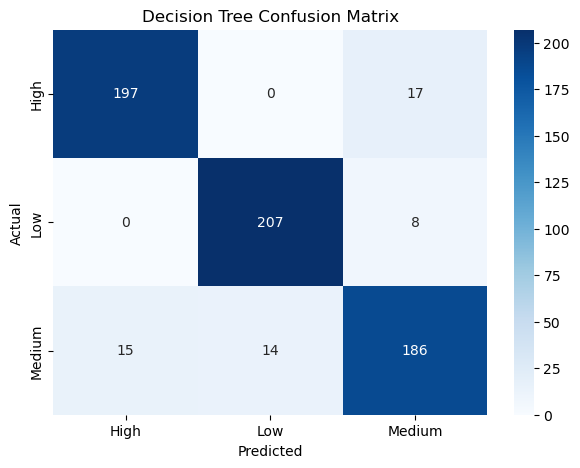

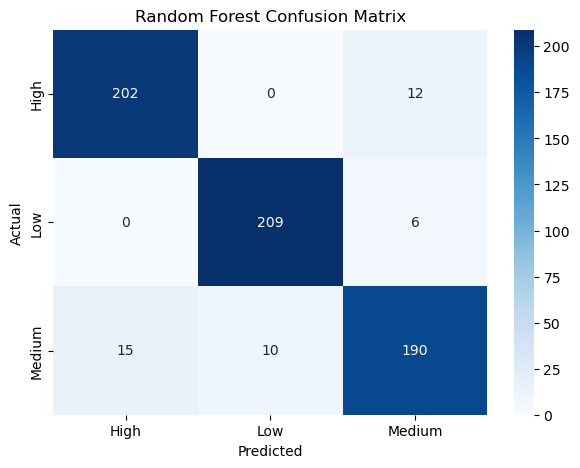

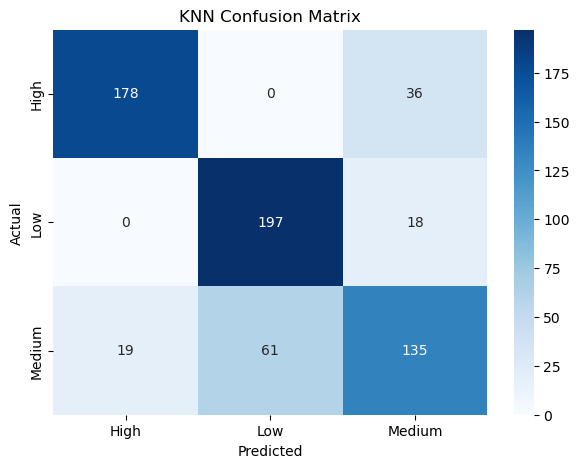

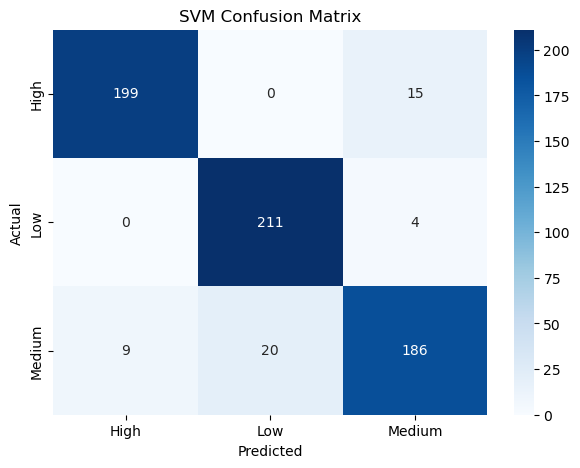

In [17]:
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred, labels=models[name].classes_)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=models[name].classes_,
        yticklabels=models[name].classes_
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} Confusion Matrix")
    plt.show()


## Cell 18 — Random Forest Feature Importance


,Feature,Importance
8,pollutant_max,0.504320
7,pollutant_min,0.320460
6,pollutant_id,0.052353
4,latitude,0.034198
5,longitude,0.028766
3,station,0.025492
2,city,0.020213
1,state,0.014199
0,country,0.000000


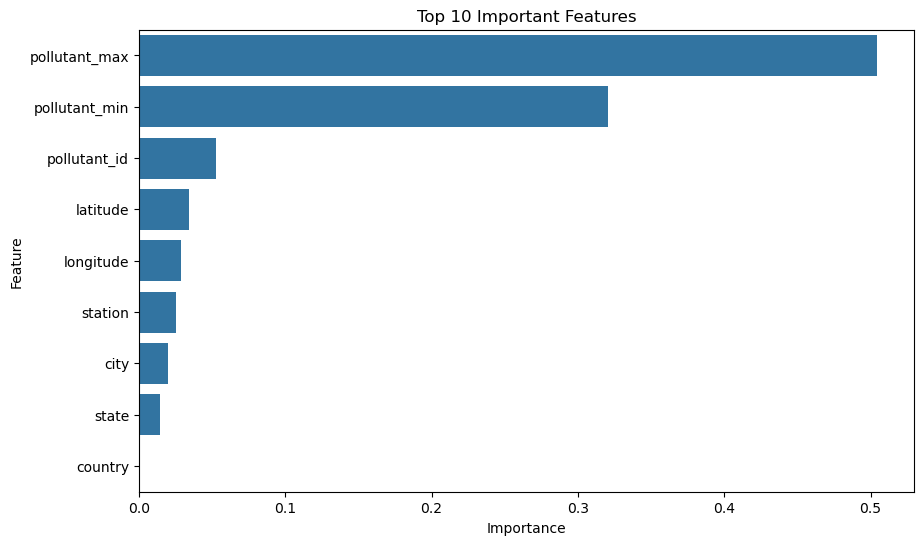

In [18]:
rf_model = models["Random Forest"]

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature")
plt.title("Top 10 Important Features")
plt.show()


## Cell 19 — Hyperparameter Tuning


In [19]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)


Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.9370873786407767


##  Evaluate Tuned Random Forest


TUNED RANDOM FOREST PERFORMANCE
Accuracy: 0.9332298136645962
Precision: 0.9330635202763996
Recall: 0.9332298136645962
F1 Score: 0.9331233910046778

Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.94      0.93       214
         Low       0.96      0.97      0.97       215
      Medium       0.91      0.89      0.90       215

    accuracy                           0.93       644
   macro avg       0.93      0.93      0.93       644
weighted avg       0.93      0.93      0.93       644



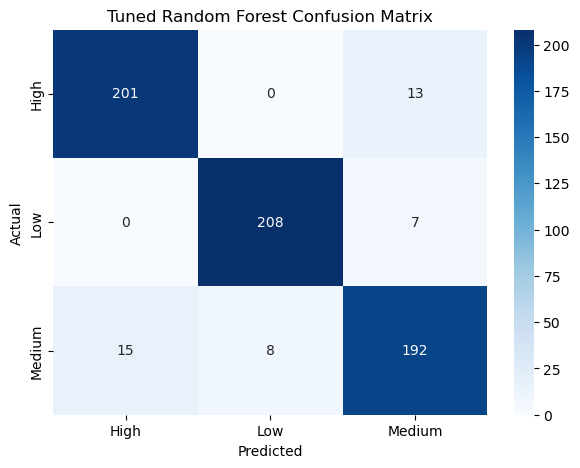

In [20]:
y_pred_best_rf = best_rf_model.predict(X_test)

accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
precision_best_rf = precision_score(y_test, y_pred_best_rf, average="weighted", zero_division=0)
recall_best_rf = recall_score(y_test, y_pred_best_rf, average="weighted", zero_division=0)
f1_best_rf = f1_score(y_test, y_pred_best_rf, average="weighted", zero_division=0)

print("TUNED RANDOM FOREST PERFORMANCE")
print("Accuracy:", accuracy_best_rf)
print("Precision:", precision_best_rf)
print("Recall:", recall_best_rf)
print("F1 Score:", f1_best_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf, zero_division=0))

cm_best_rf = confusion_matrix(y_test, y_pred_best_rf, labels=best_rf_model.classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_best_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_rf_model.classes_,
    yticklabels=best_rf_model.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()


## Save Model and Preprocessing Objects


In [21]:
joblib.dump(best_rf_model, "air_quality_classification_model.pkl")
joblib.dump(imputer, "classification_imputer.pkl")
joblib.dump(scaler, "classification_scaler.pkl")
joblib.dump(label_encoders, "classification_label_encoders.pkl")
joblib.dump(X.columns.tolist(), "classification_feature_columns.pkl")

print("Model and preprocessing files saved successfully!")


Model and preprocessing files saved successfully!


##  Final Summary


In [22]:
print("=" * 60)
print("AIR QUALITY CLASSIFICATION PROJECT COMPLETED")
print("=" * 60)
print("Target:", "pollution_class")
print("\nClass distribution:")
print(y.value_counts())
print("\nNumber of records:", len(df))
print("Number of features:", X_imputed.shape[1])
print("\nModel comparison:")
display(results)
print("\nBest model:", best_model_name)
print("Best model accuracy:", best_accuracy)
print("Tuned Random Forest accuracy:", accuracy_best_rf)


AIR QUALITY CLASSIFICATION PROJECT COMPLETED
Target: pollution_class

Class distribution:
pollution_class
Low       1073
Medium    1073
High      1073
Name: count, dtype: int64

Number of records: 3219
Number of features: 9

Model comparison:


,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.933230,0.932895,0.933230,0.932938
0,Logistic Regression,0.931677,0.931707,0.931677,0.931177
4,SVM,0.925466,0.925775,0.925466,0.924982
1,Decision Tree,0.916149,0.915784,0.916149,0.915874
3,KNN,0.791925,0.793631,0.791925,0.789040



Best model: Random Forest
Best model accuracy: 0.9332298136645962
Tuned Random Forest accuracy: 0.9332298136645962
